In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [14]:
df = pd.read_csv("telco-customer-churn.csv")
print(df.shape)
print(df.head())

(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

In [15]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()
df_original = df.copy()

if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)
if 'customerID' in df_original.columns:
    df_original = df_original.drop('customerID', axis=1)

df_original = df_original.dropna(subset=['TotalCharges'])

print(df.shape)
print(df.dtypes)

(7032, 20)
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


In [16]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [18]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype.kind not in ('i', 'f', 'u'): 
        df[col] = le.fit_transform(df[col].astype(str))

print(df.dtypes)

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


In [19]:
print("Churn Value Counts:")
print(df_original['Churn'].value_counts())
print("\nChurn Percentage:")
print(df_original['Churn'].value_counts(normalize=True) * 100)

Churn Value Counts:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


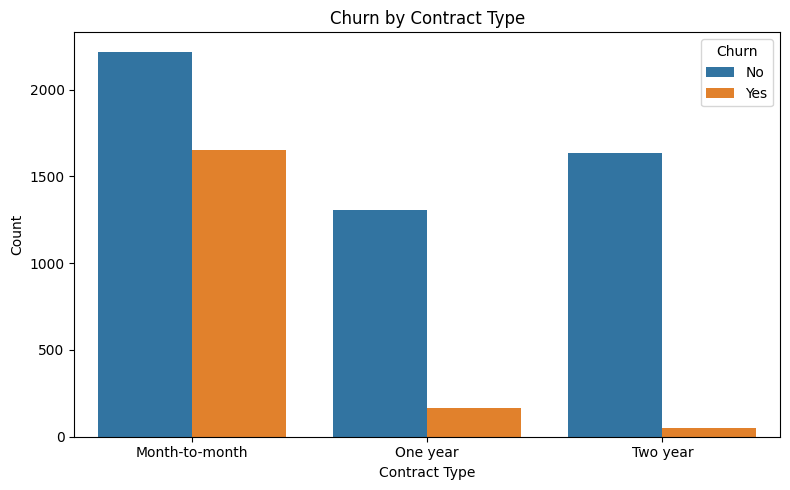

In [25]:
import seaborn as sns
plt.figure(figsize=(8,5))
sns.countplot(data=df_original, x='Contract', hue='Churn')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

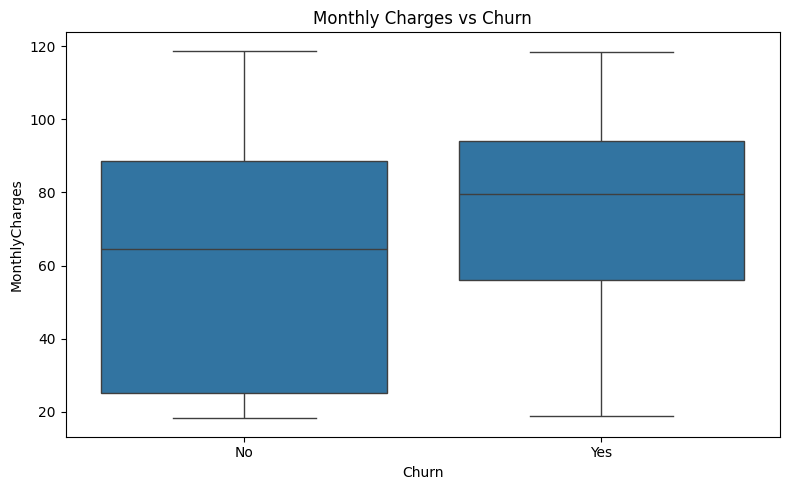

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_original, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges vs Churn')
plt.tight_layout()
plt.show()

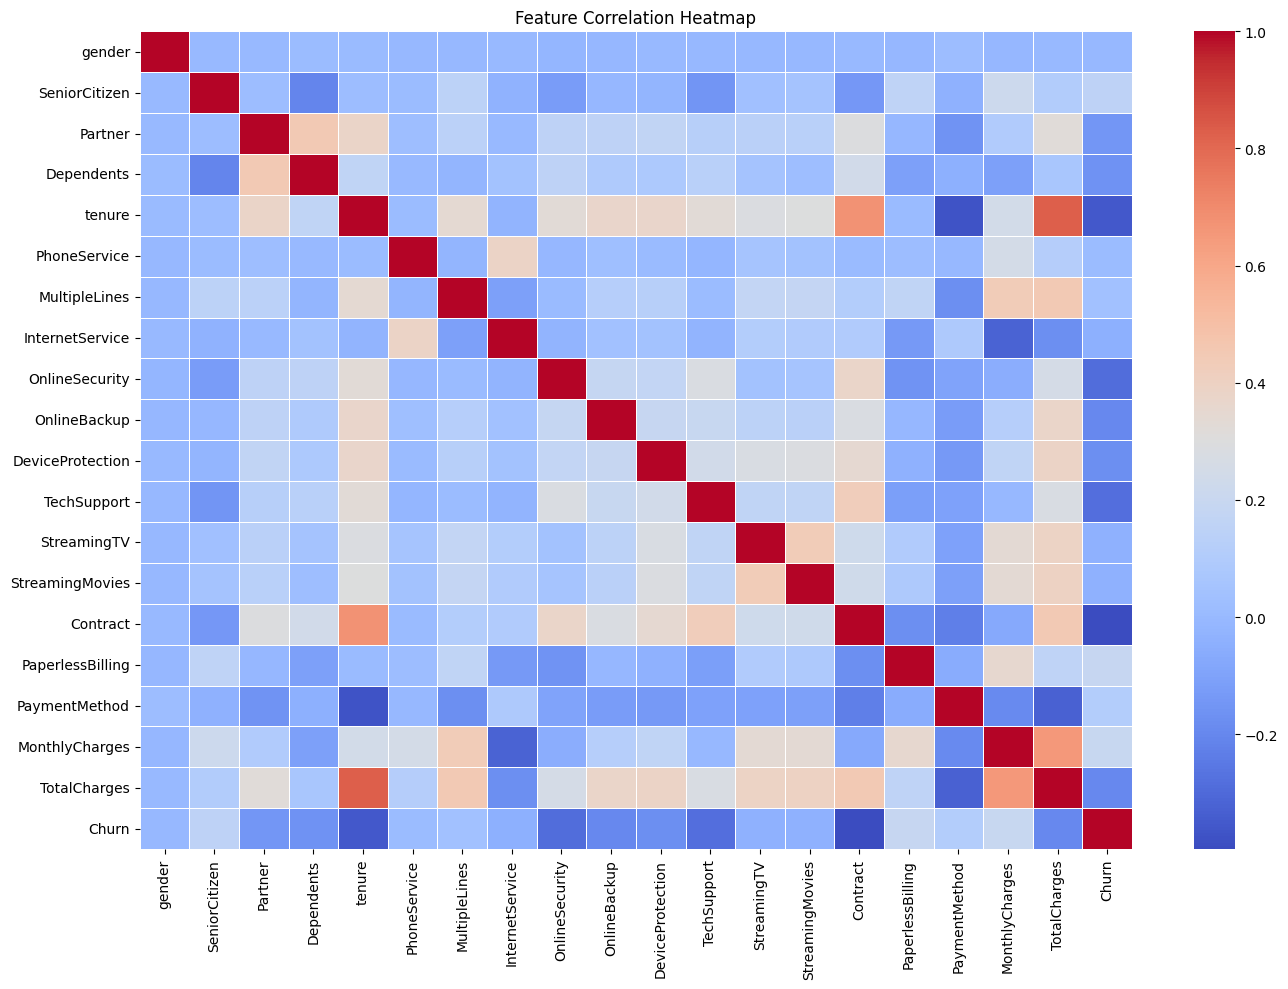

In [27]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

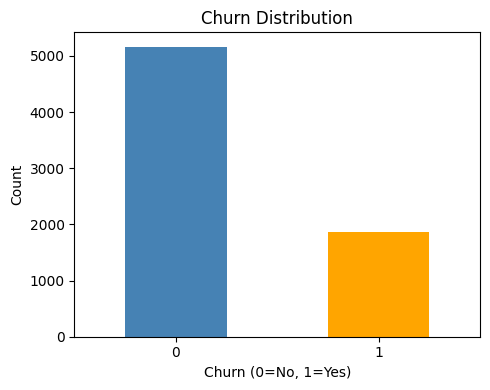

In [28]:
plt.figure(figsize=(5,4))
df['Churn'].value_counts().plot(kind='bar', color=['steelblue','orange'])
plt.title('Churn Distribution')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [40]:
X = df.drop('Churn', axis=1)
y = df['Churn']
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7032, 19)
y shape: (7032,)


In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (5625, 19)
Test size: (1407, 19)


In [42]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Scaling done!")

Scaling done!


In [43]:
lr = LogisticRegression(max_iter=5000, solver='saga')
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Model trained!")

Model trained!


In [44]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.7853589196872779

Confusion Matrix:
[[920 113]
 [189 185]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



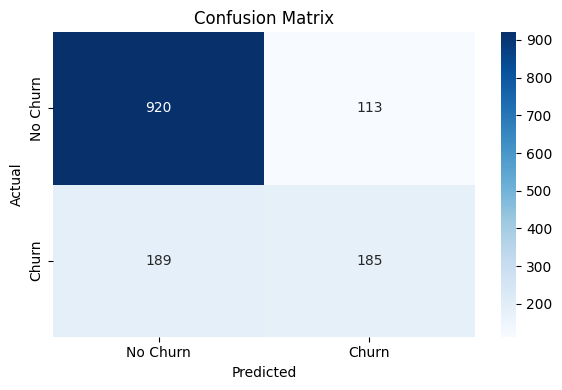

In [45]:
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

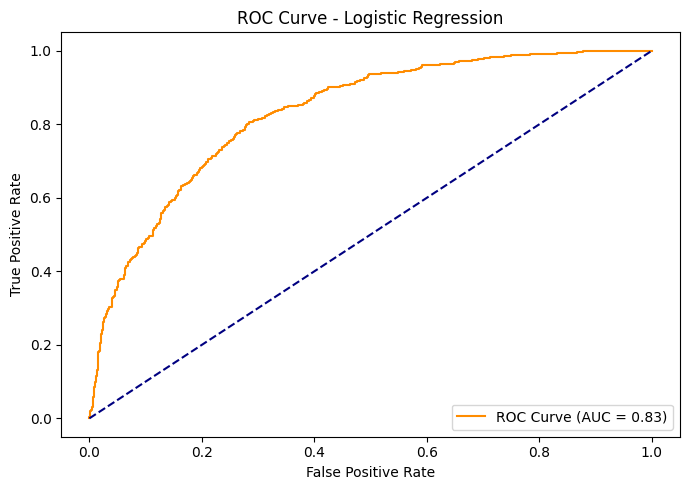

In [46]:
y_prob = lr.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0,1], [0,1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [47]:
feature_importances = pd.Series(abs(lr.coef_[0]), index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)
print("Top 10 Important Features:")
print(feature_importances.head(10))

Top 10 Important Features:
tenure              1.428295
MonthlyCharges      0.703016
TotalCharges        0.663262
Contract            0.611092
PhoneService        0.307063
OnlineSecurity      0.251899
TechSupport         0.242285
InternetService     0.189015
PaperlessBilling    0.147671
Dependents          0.108358
dtype: float64


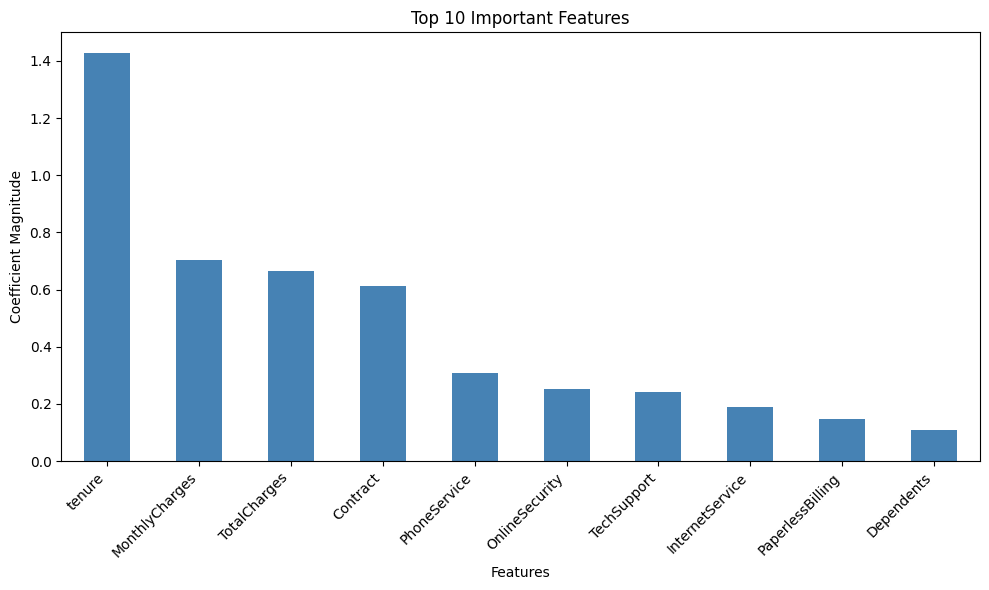

In [48]:
plt.figure(figsize=(10,6))
feature_importances.head(10).plot(kind='bar', color='steelblue')
plt.title('Top 10 Important Features')
plt.xlabel('Features')
plt.ylabel('Coefficient Magnitude')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [53]:
models = {
    'Logistic Regression': lr,
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

accuracies = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    accuracies[name] = accuracy_score(y_test, pred)
    print(f"{name}: {accuracies[name]:.4f}")

Logistic Regression: 0.7854
Random Forest: 0.7903
Decision Tree: 0.7249


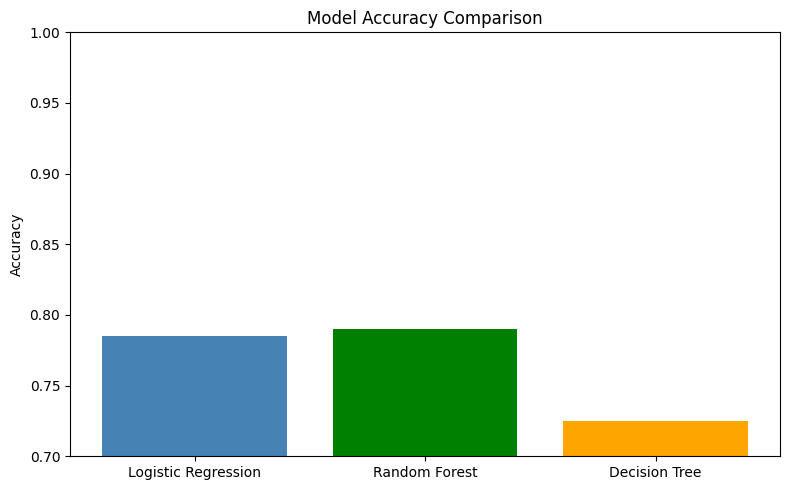

In [54]:
plt.figure(figsize=(8,5))
plt.bar(accuracies.keys(), accuracies.values(),
        color=['steelblue', 'green', 'orange'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.7, 1.0)
plt.tight_layout()
plt.show()

In [55]:
cv_scores = cross_val_score(lr, X_train, y_train, cv=5, scoring='accuracy')
print("Cross Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean().round(4))
print("Std CV Accuracy:", cv_scores.std().round(4))

Cross Validation Scores: [0.81688889 0.80711111 0.78666667 0.79911111 0.81688889]
Mean CV Accuracy: 0.8053
Std CV Accuracy: 0.0115
